In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
import pmdarima as pm
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr

In [2]:
p22 = pd.read_csv('../data/processed_22.csv')
p23 = pd.read_csv('../data/processed_23.csv')
p24 = pd.read_csv('../data/processed_24.csv')
p25 = pd.read_csv('../data/processed_25.csv')
combined = pd.concat([p22, p23, p24, p25], ignore_index=True)

s = combined[["date", "Lpoly_expected_ml"]].copy()
s["date"] = pd.to_datetime(s["date"].astype(str), format="%Y%m%d")
s = s.sort_values("date").set_index("date").asfreq("D")

# EMA imputation
ema = s["Lpoly_expected_ml"].ewm(span=30, adjust=False).mean()
s["Lpoly_expected_ml"] = s["Lpoly_expected_ml"].fillna(ema)

# normalization
y = s["Lpoly_expected_ml"].values
y_norm = (y - y.mean()) / y.std()

In [3]:
model_auto = pm.auto_arima(
    y_norm,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=None,              # let it decide
    seasonal=False,      # no seasonality
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore"
)

print(model_auto)

order = model_auto.order  # or best_order
arima = ARIMA(y_norm, order=order)
arima_fit = arima.fit()

print(arima_fit)

 ARIMA(4,0,0)(0,0,0)[0]          


In [4]:
def rolling_arima_forecast(y, order, Tp, train_frac=0.8):
    n = len(y)
    train_end = int(train_frac * n)

    preds = []
    obs = []

    for t in range(train_end, n - Tp):
        model = ARIMA(y[:t], order=order)
        fit = model.fit()
        forecast = fit.forecast(steps=Tp)[-1]

        preds.append(forecast)
        obs.append(y[t + Tp])

    preds = np.array(preds)
    obs = np.array(obs)
    
    if len(preds) < 5:
        return np.nan, np.nan, np.nan

    rho = pearsonr(preds, obs)[0]
    rmse = np.sqrt(mean_squared_error(obs, preds))
    mae = mean_absolute_error(obs, preds)

    return rho, rmse, mae

In [5]:
results = []

for Tp in range(1, 32):
    rho, rmse, mae = rolling_arima_forecast(
        y_norm,
        order=order,
        Tp=Tp,
        train_frac=0.8
    )

    results.append({
        "Tp": Tp,
        "rho": rho,
        "rmse": rmse,
        "mae": mae
    })

df_arima = pd.DataFrame(results)
df_arima

,Tp,rho,rmse,mae
0,1,0.318791,0.063311,0.063135
1,2,0.221032,0.116911,0.116620
2,3,0.193756,0.151901,0.151537
3,4,0.189295,0.170163,0.169767
4,5,0.185839,0.185813,0.185393
5,6,0.178034,0.201523,0.201080
6,7,0.180214,0.215996,0.215533
7,8,0.183321,0.227389,0.226914
8,9,0.181596,0.236048,0.235564
9,10,0.184001,0.242944,0.242457


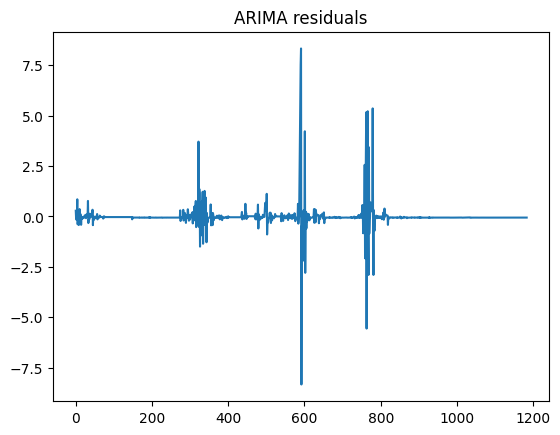

In [6]:
resid = arima_fit.resid

plt.figure()
plt.plot(resid)
plt.title("ARIMA residuals")
plt.show()

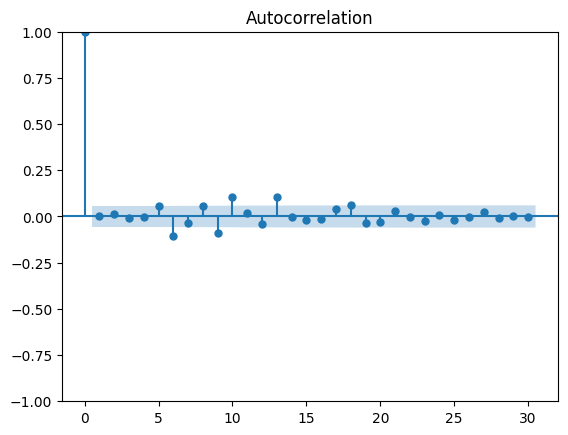

In [7]:
plot_acf(resid, lags=30)
plt.show()